# Seasonal Agriculture Performance Analysis
**VOIS AICTE Batch 2026-2027 — Major Project**

This notebook analyses how agricultural performance (yield, cost, revenue, profit, resource usage) varies across seasons (Kharif, Rabi, Zaid), and identifies patterns, relationships and recommendations based on the evidence in the data.

## 1. Importing Libraries

In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Try to import statsmodels for Tukey post-hoc test (optional, used later)
try:
    from statsmodels.stats.multicomp import pairwise_tukeyhsd
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels not found - Tukey post-hoc test cell will be skipped. "
          "Install with: pip install statsmodels")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)


## 2. Creating the DataFrame

In [2]:
# Creating DataFrame
df = pd.read_csv("seasonal_agri.csv")


## 3. Analysing Shape and Structure of Data
> **Key Question (from Project PDF):** *Explore and understand the dataset.*

In [3]:
# Analysing Top 5 rows
df.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [4]:
# Analysing bottom 5 rows
df.tail()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.4,27.3,51.4,6.3,7.97,27.3,104.3,44.8,94.0,Drip,271.1,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.195,45.2
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.5,29.2,85.5,6.1,6.57,33.7,127.8,44.9,91.3,Drip,176.6,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.508,59.7
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.0,35.4,68.5,8.6,7.25,21.1,126.7,59.9,148.0,Drip,234.7,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.913,29.2
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.0,28.2,61.7,6.4,6.11,30.5,107.5,20.7,91.0,Sprinkler,329.7,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.918,50.4
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.3,25.8,77.2,5.9,6.16,35.7,137.1,92.6,145.5,Sprinkler,205.9,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.339,62.3


In [5]:
# Analysing Shape
print("SHAPE : (Rows, Column) ->", df.shape)


SHAPE : (Rows, Column) -> (4000, 28)


In [6]:
# Columns Names
columns = []
print("Columns :")
for i in df.columns:
    print("   ", i)
    columns.append(i)


Columns :
    Farm_ID
    State
    District
    Crop
    Season
    Farm_Area_Hectares
    Rainfall_mm
    Avg_Temperature_C
    Humidity_pct
    Sunlight_Hours_Day
    Soil_pH
    Soil_Moisture_pct
    Nitrogen_kg_ha
    Phosphorus_kg_ha
    Potassium_kg_ha
    Irrigation_Method
    Fertilizer_kg_ha
    Pesticide_Litre_ha
    Seed_Quality_Score
    Yield_Tonnes_Ha
    Production_Tonnes
    Market_Price_INR_Tonne
    Total_Cost_INR
    Revenue_INR
    Profit_INR
    Water_Used_m3
    Water_Efficiency_t_per_1000m3
    Disease_Pest_Risk_pct


In [7]:
# Analysing Statistic Info
df.describe().T  # T for transpose


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [9]:
# Separate numeric and categorical columns for later use
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)


Categorical columns: ['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']

Numeric columns: ['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


## 4. Handling Missing Values and Duplicates
> **Key Question (from Project PDF):** *Clean and prepare the data for analysis.*

In [10]:
print("NULL VALUES :")
df.isnull().sum()


NULL VALUES :


Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest_Risk_pct       

In [11]:
# Percentage of Missing Values
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage[missing_percentage > 0]


Rainfall_mm          1.2
Soil_Moisture_pct    1.0
Yield_Tonnes_Ha      0.8
dtype: float64

In [12]:
# Analysing Duplicate Values
print("DUPLICATE ROWS :", df.duplicated().sum())


DUPLICATE ROWS : 0


### 4.1 Treating Missing Values
`Rainfall_mm`, `Soil_Moisture_pct` and `Yield_Tonnes_Ha` have a small percentage of missing values (~1%). Since these vary strongly by **Season**, we impute them using the **median value for that Season** rather than a single global median — this keeps the seasonal signal in the data intact.

In [13]:
df_clean = df.copy()

cols_to_impute = ["Rainfall_mm", "Soil_Moisture_pct", "Yield_Tonnes_Ha"]

for col in cols_to_impute:
    df_clean[col] = df_clean.groupby("Season")[col].transform(
        lambda x: x.fillna(x.median())
    )

print("Remaining missing values after imputation:")
print(df_clean.isnull().sum().sum())


Remaining missing values after imputation:
0


### 4.2 Outlier Check
A few economic/yield columns (e.g. `Yield_Tonnes_Ha`, `Production_Tonnes`, `Revenue_INR`, `Profit_INR`) have very large maximum values compared to their 75th percentile (seen in `describe()` above), suggesting outliers. We visualise them first before deciding how to treat them.

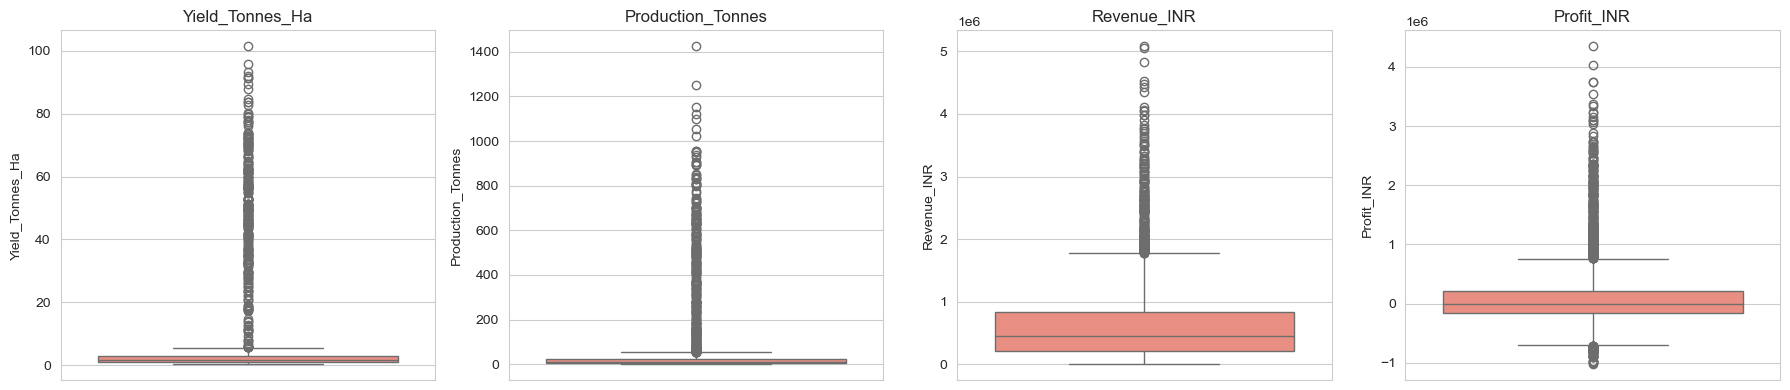

In [14]:
outlier_check_cols = ["Yield_Tonnes_Ha", "Production_Tonnes", "Revenue_INR", "Profit_INR"]

fig, axes = plt.subplots(1, len(outlier_check_cols), figsize=(18, 4))
for ax, col in zip(axes, outlier_check_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color="salmon")
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [15]:
# Quantify outliers using the IQR method
def iqr_outlier_count(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    return ((series < lower) | (series > upper)).sum()

for col in outlier_check_cols:
    print(f"{col}: {iqr_outlier_count(df_clean[col])} outlier rows "
          f"({iqr_outlier_count(df_clean[col]) / len(df_clean) * 100:.1f}%)")


Yield_Tonnes_Ha: 302 outlier rows (7.5%)
Production_Tonnes: 333 outlier rows (8.3%)
Revenue_INR: 240 outlier rows (6.0%)
Profit_INR: 404 outlier rows (10.1%)


These extreme values likely represent genuinely exceptional (very high-yield / very high-loss) farms rather than data-entry errors, so instead of deleting them we **cap (winsorize)** them at the 1st and 99th percentile. This reduces their distorting effect on means and charts while keeping every row in the analysis.

In [16]:
def cap_outliers(series, lower_q=0.01, upper_q=0.99):
    lower, upper = series.quantile(lower_q), series.quantile(upper_q)
    return series.clip(lower, upper)

for col in outlier_check_cols:
    df_clean[col] = cap_outliers(df_clean[col])

print("Outliers capped at the 1st/99th percentile for:", outlier_check_cols)


Outliers capped at the 1st/99th percentile for: ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR', 'Profit_INR']


## 5. Feature Engineering
A few derived metrics make seasonal comparison more meaningful than the raw columns alone (e.g. comparing profit *per hectare* instead of absolute profit, which is biased by farm size).

In [17]:
# Enforce a natural season order for all plots (India: Kharif -> Rabi -> Zaid)
season_order = [s for s in ["Kharif", "Rabi", "Zaid"] if s in df_clean["Season"].unique()]
df_clean["Season"] = pd.Categorical(df_clean["Season"], categories=season_order, ordered=True)

# Derived economic metrics
df_clean["Cost_per_Hectare"]   = df_clean["Total_Cost_INR"] / df_clean["Farm_Area_Hectares"]
df_clean["Revenue_per_Hectare"] = df_clean["Revenue_INR"] / df_clean["Farm_Area_Hectares"]
df_clean["Profit_per_Hectare"] = df_clean["Profit_INR"] / df_clean["Farm_Area_Hectares"]
df_clean["Profit_Margin_pct"]  = (df_clean["Profit_INR"] / df_clean["Revenue_INR"]) * 100
df_clean["ROI_pct"]            = (df_clean["Profit_INR"] / df_clean["Total_Cost_INR"]) * 100
df_clean["Is_Profitable"]      = df_clean["Profit_INR"] > 0

df_clean[["Season", "Cost_per_Hectare", "Revenue_per_Hectare",
          "Profit_per_Hectare", "Profit_Margin_pct", "ROI_pct", "Is_Profitable"]].head()


,Season,Cost_per_Hectare,Revenue_per_Hectare,Profit_per_Hectare,Profit_Margin_pct,ROI_pct,Is_Profitable
0,Kharif,80494.339623,58132.075472,-22362.264151,-38.468030,-27.781164,False
1,Kharif,75398.315467,6186.983155,-69211.332312,-1118.660429,-91.794269,False
2,Rabi,64858.024691,39190.534979,-25667.489712,-65.494104,-39.574887,False
3,Kharif,65876.444444,44608.888889,-21267.555556,-47.675600,-32.284006,False
4,Zaid,80275.296912,45987.410926,-34287.885986,-74.559288,-42.712873,False


## 6. Univariate Analysis — Understanding the Categories
> **Key Question (from Project PDF):** *Which characteristics (Season, Crop, State, Irrigation Method) make up the dataset?*

C:\Users\athar\AppData\Local\Temp\ipykernel_39140\321010281.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="Season", order=season_order, ax=axes[0], palette="viridis")
C:\Users\athar\AppData\Local\Temp\ipykernel_39140\321010281.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y="Crop",


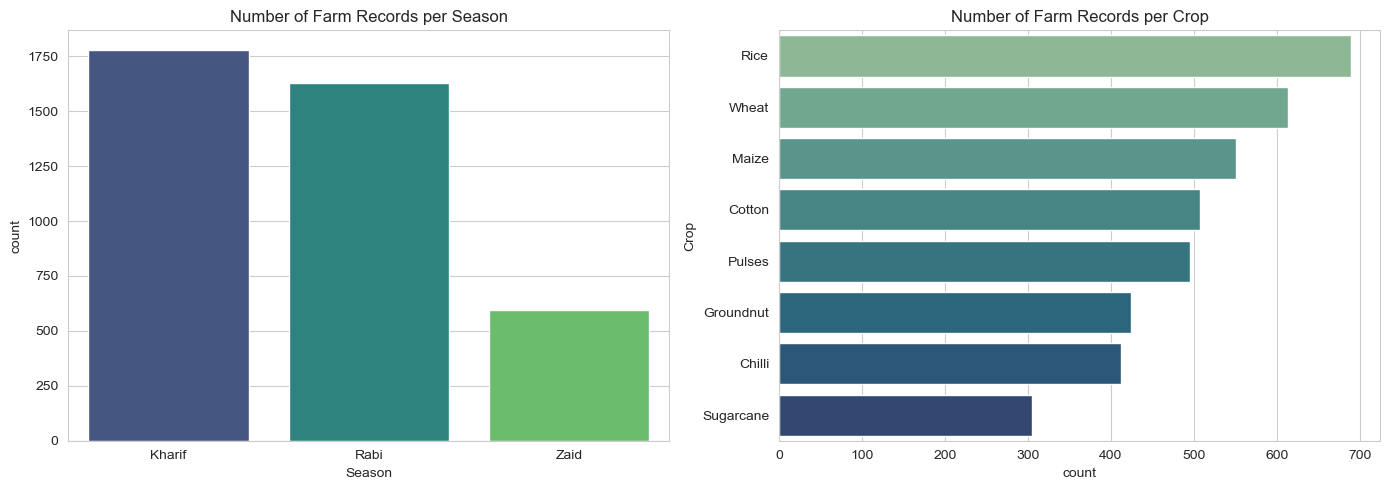

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, x="Season", order=season_order, ax=axes[0], palette="viridis")
axes[0].set_title("Number of Farm Records per Season")

sns.countplot(data=df_clean, y="Crop",
              order=df_clean["Crop"].value_counts().index, ax=axes[1], palette="crest")
axes[1].set_title("Number of Farm Records per Crop")

plt.tight_layout()
plt.show()


C:\Users\athar\AppData\Local\Temp\ipykernel_39140\2232223100.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, y="State",
C:\Users\athar\AppData\Local\Temp\ipykernel_39140\2232223100.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="Irrigation_Method",


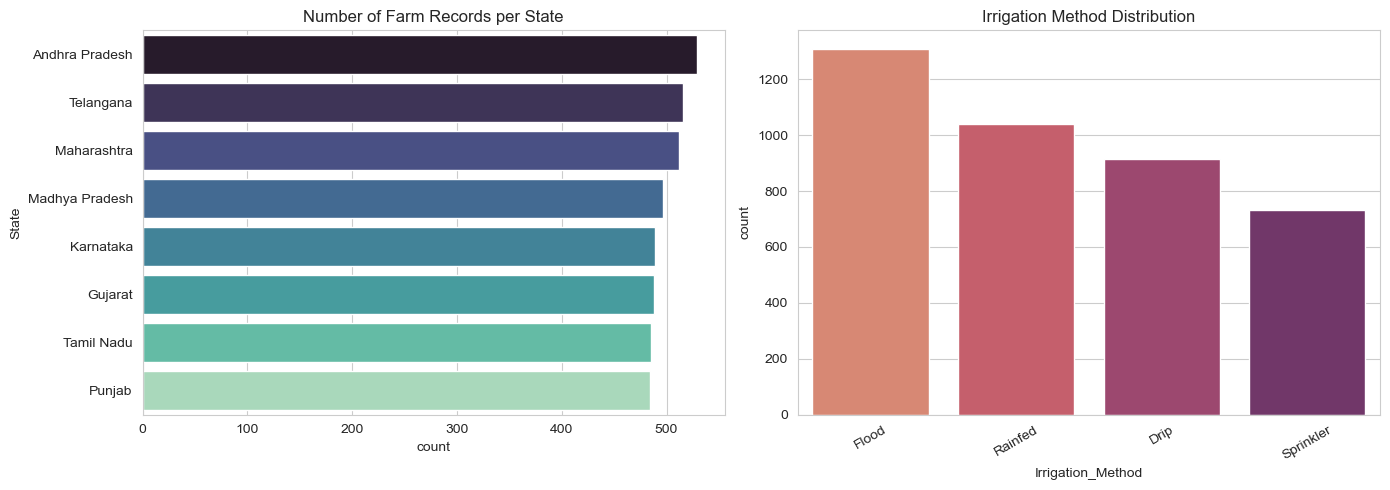

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_clean, y="State",
              order=df_clean["State"].value_counts().index, ax=axes[0], palette="mako")
axes[0].set_title("Number of Farm Records per State")

sns.countplot(data=df_clean, x="Irrigation_Method",
              order=df_clean["Irrigation_Method"].value_counts().index,
              ax=axes[1], palette="flare")
axes[1].set_title("Irrigation Method Distribution")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 7. Seasonal Performance Overview
> **Key Question (from Project PDF):** *How does agricultural performance vary across seasons? What major seasonal patterns can be observed?*

This directly addresses the core question: **How does agricultural performance vary across seasons?**

In [20]:
performance_cols = ["Yield_Tonnes_Ha", "Production_Tonnes", "Revenue_INR",
                     "Total_Cost_INR", "Profit_INR", "ROI_pct",
                     "Water_Used_m3", "Water_Efficiency_t_per_1000m3"]

seasonal_summary = df_clean.groupby("Season", observed=True)[performance_cols].mean().round(2)
seasonal_summary


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,ROI_pct,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,,
Kharif,5.50,43.79,699997.19,531804.41,170100.80,34.42,6102.20,5.89
Rabi,4.98,39.90,599512.48,513836.58,86254.12,17.38,5846.99,5.19
Zaid,4.64,38.27,518708.77,543976.73,-23234.61,-2.32,6419.89,4.41


C:\Users\athar\AppData\Local\Temp\ipykernel_39140\118554643.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="Season", y="Yield_Tonnes_Ha", order=season_order,
C:\Users\athar\AppData\Local\Temp\ipykernel_39140\118554643.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="Season", y="Profit_INR", order=season_order,
C:\Users\athar\AppData\Local\Temp\ipykernel_39140\118554643.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x="Season", y="ROI_pct", order=season_order,


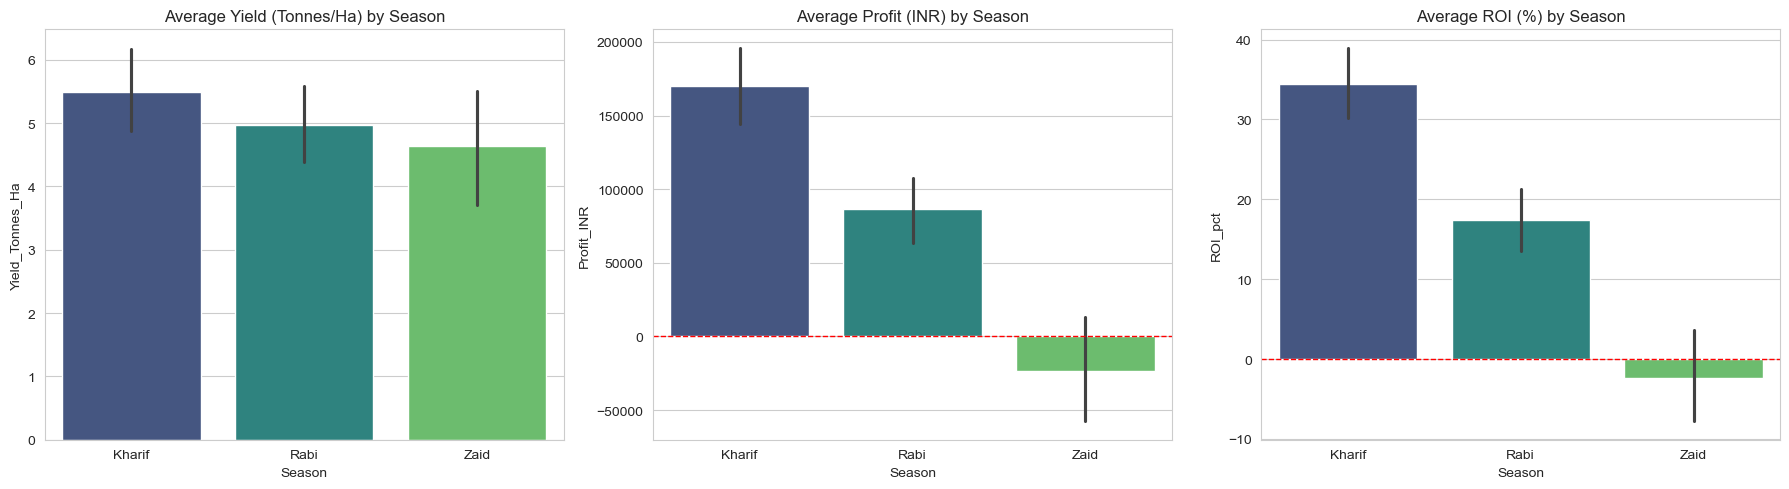

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df_clean, x="Season", y="Yield_Tonnes_Ha", order=season_order,
            estimator=np.mean, ax=axes[0], palette="viridis")
axes[0].set_title("Average Yield (Tonnes/Ha) by Season")

sns.barplot(data=df_clean, x="Season", y="Profit_INR", order=season_order,
            estimator=np.mean, ax=axes[1], palette="viridis")
axes[1].set_title("Average Profit (INR) by Season")
axes[1].axhline(0, color="red", linewidth=1, linestyle="--")

sns.barplot(data=df_clean, x="Season", y="ROI_pct", order=season_order,
            estimator=np.mean, ax=axes[2], palette="viridis")
axes[2].set_title("Average ROI (%) by Season")
axes[2].axhline(0, color="red", linewidth=1, linestyle="--")

plt.tight_layout()
plt.show()


C:\Users\athar\AppData\Local\Temp\ipykernel_39140\3356653926.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y="Yield_Tonnes_Ha", order=season_order,
C:\Users\athar\AppData\Local\Temp\ipykernel_39140\3356653926.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y="Profit_per_Hectare", order=season_order,


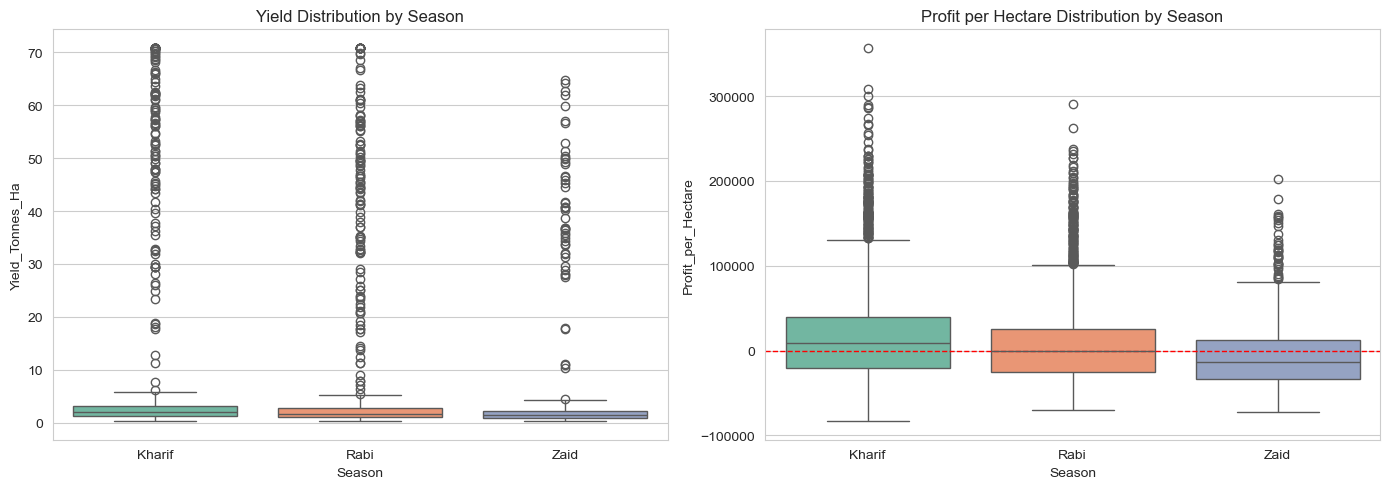

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x="Season", y="Yield_Tonnes_Ha", order=season_order,
            ax=axes[0], palette="Set2")
axes[0].set_title("Yield Distribution by Season")

sns.boxplot(data=df_clean, x="Season", y="Profit_per_Hectare", order=season_order,
            ax=axes[1], palette="Set2")
axes[1].set_title("Profit per Hectare Distribution by Season")
axes[1].axhline(0, color="red", linewidth=1, linestyle="--")

plt.tight_layout()
plt.show()


## 8. Environmental Conditions Across Seasons
> **Key Question (from Project PDF):** *Which characteristics change between seasons? Are there noticeable variations in environmental conditions across seasons?*

C:\Users\athar\AppData\Local\Temp\ipykernel_39140\2025359750.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y=col, order=season_order, ax=ax, palette="coolwarm")
C:\Users\athar\AppData\Local\Temp\ipykernel_39140\2025359750.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y=col, order=season_order, ax=ax, palette="coolwarm")
C:\Users\athar\AppData\Local\Temp\ipykernel_39140\2025359750.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y=col, order=season

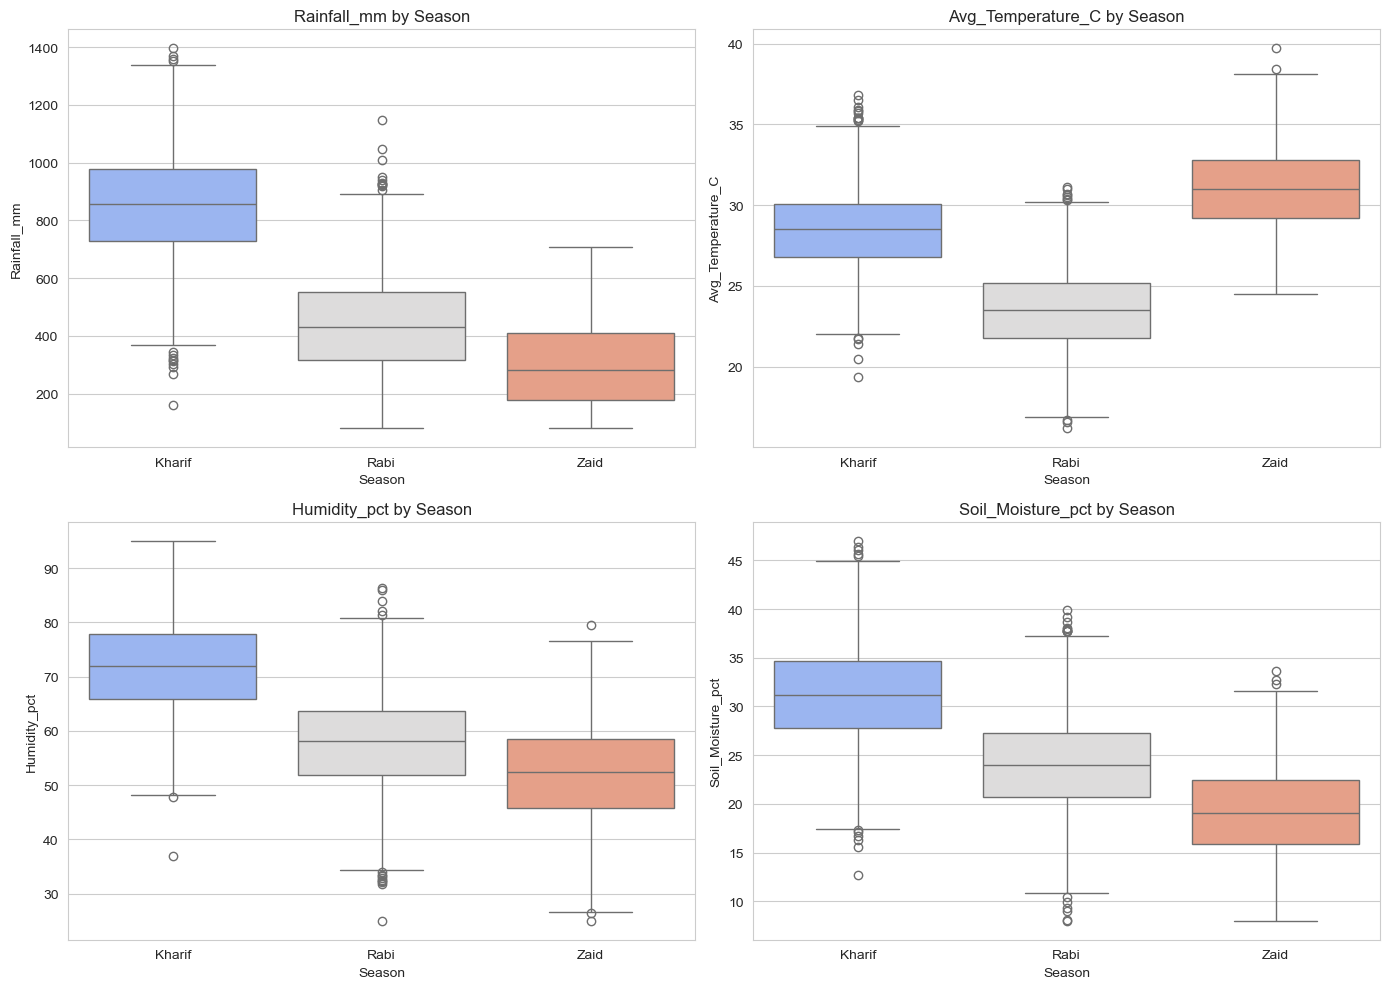

In [23]:
env_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_Moisture_pct"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), env_cols):
    sns.boxplot(data=df_clean, x="Season", y=col, order=season_order, ax=ax, palette="coolwarm")
    ax.set_title(f"{col} by Season")

plt.tight_layout()
plt.show()


In [24]:
df_clean.groupby("Season", observed=True)[env_cols].mean().round(2)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct
Season,,,,
Kharif,852.11,28.45,71.81,31.20
Rabi,435.94,23.49,57.89,24.05
Zaid,299.12,31.04,52.01,19.17


## 9. Resource Usage Across Seasons
> **Key Question (from Project PDF):** *What differences exist in agricultural activities between seasons? Are there noticeable variations in resource usage across seasons?*

In [25]:
resource_cols = ["Fertilizer_kg_ha", "Pesticide_Litre_ha", "Water_Used_m3",
                  "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha"]

resource_summary = df_clean.groupby("Season", observed=True)[resource_cols].mean().round(2)
resource_summary


,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha
Season,,,,,,
Kharif,187.08,5.08,6102.20,120.02,58.10,105.30
Rabi,185.41,5.02,5846.99,120.40,57.31,103.93
Zaid,184.64,5.17,6419.89,120.53,58.13,105.42


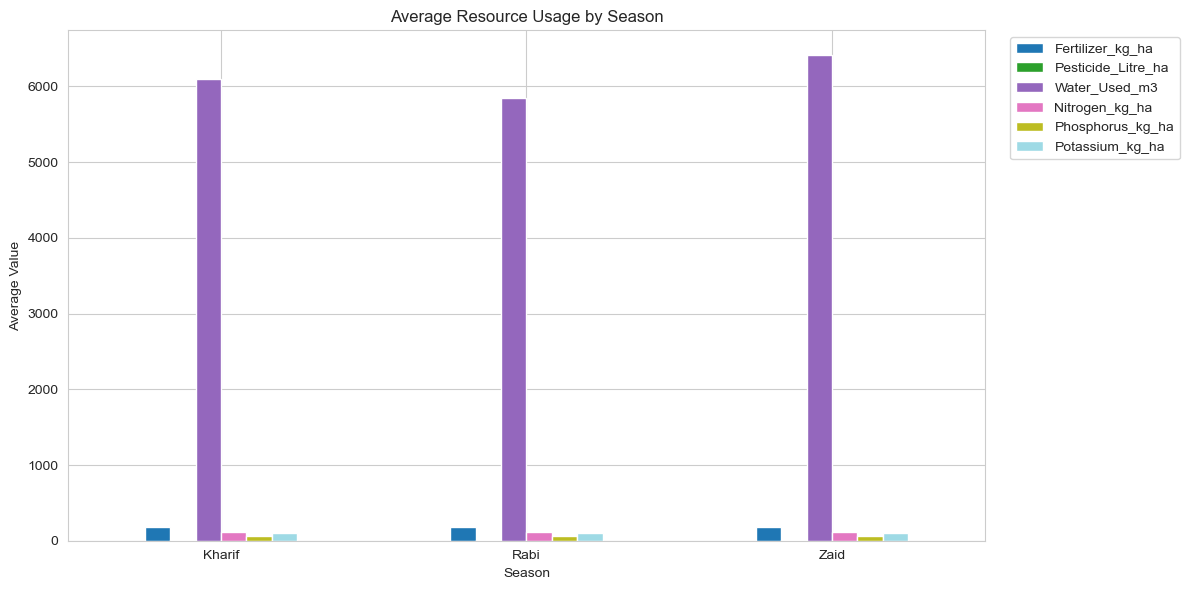

In [26]:
resource_summary.plot(kind="bar", figsize=(12, 6), colormap="tab20")
plt.title("Average Resource Usage by Season")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


C:\Users\athar\AppData\Local\Temp\ipykernel_39140\4256403881.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y="Water_Efficiency_t_per_1000m3",


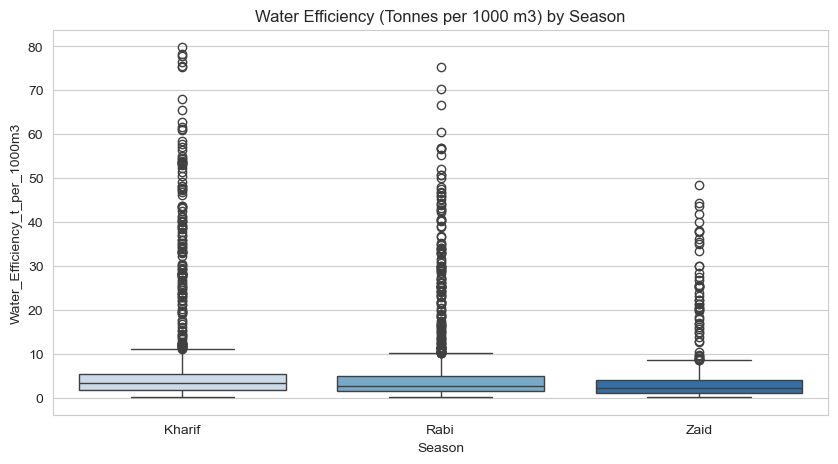

In [27]:
sns.boxplot(data=df_clean, x="Season", y="Water_Efficiency_t_per_1000m3",
            order=season_order, palette="Blues")
plt.title("Water Efficiency (Tonnes per 1000 m3) by Season")
plt.show()


## 10. Economic Performance Across Seasons
> **Key Question (from Project PDF):** *How do economic outcomes vary across seasons?*

C:\Users\athar\AppData\Local\Temp\ipykernel_39140\852053014.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="Season", y="Profit_Margin_pct", order=season_order,


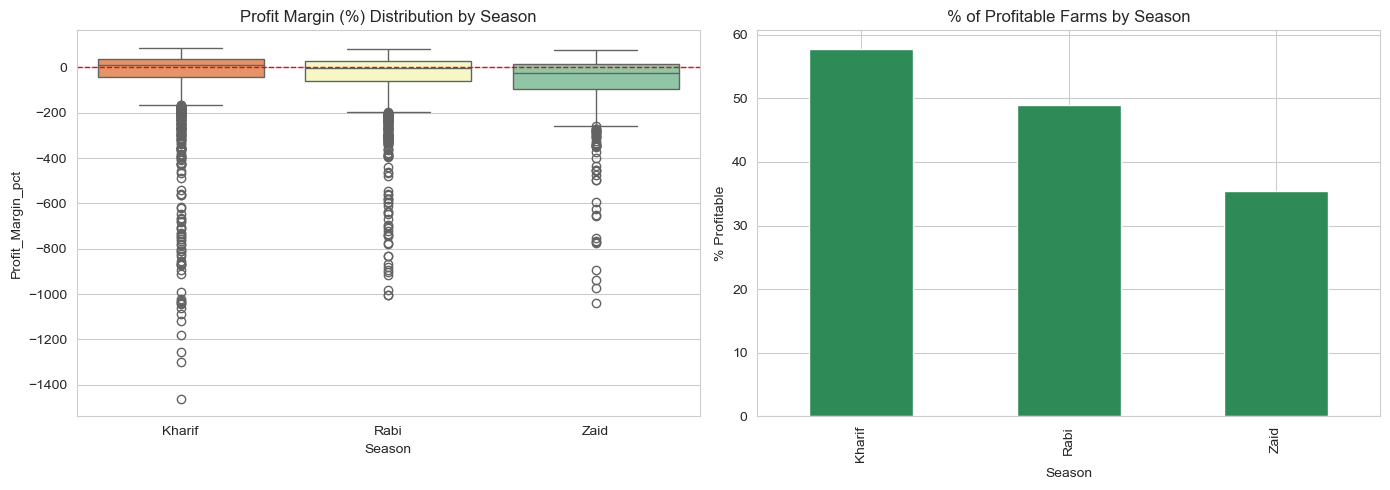

Percentage of profitable farms by season:
Season
Kharif    57.8
Rabi      48.9
Zaid      35.5
Name: Is_Profitable, dtype: float64


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x="Season", y="Profit_Margin_pct", order=season_order,
            ax=axes[0], palette="Spectral")
axes[0].set_title("Profit Margin (%) Distribution by Season")
axes[0].axhline(0, color="red", linewidth=1, linestyle="--")

profitable_pct = (df_clean.groupby("Season", observed=True)["Is_Profitable"]
                  .mean() * 100).round(1)
profitable_pct.plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("% of Profitable Farms by Season")
axes[1].set_ylabel("% Profitable")

plt.tight_layout()
plt.show()

print("Percentage of profitable farms by season:")
print(profitable_pct)


## 11. Relationships Between Variables
> **Key Question (from Project PDF):** *Are there relationships between seasonal environmental conditions and agricultural performance?*

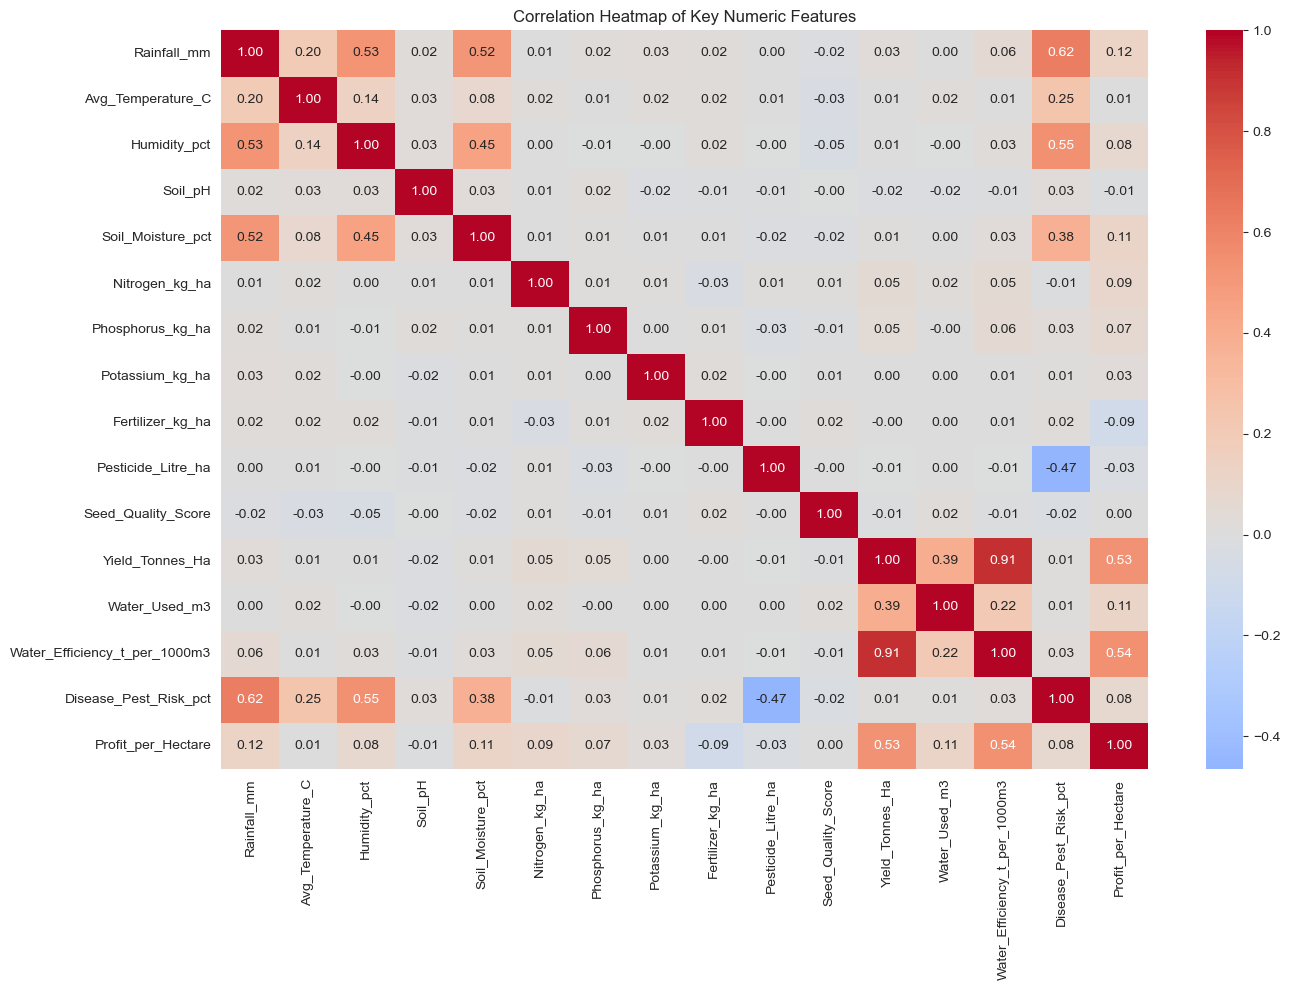

In [29]:
corr_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_pH",
             "Soil_Moisture_pct", "Nitrogen_kg_ha", "Phosphorus_kg_ha", "Potassium_kg_ha",
             "Fertilizer_kg_ha", "Pesticide_Litre_ha", "Seed_Quality_Score",
             "Yield_Tonnes_Ha", "Water_Used_m3", "Water_Efficiency_t_per_1000m3",
             "Disease_Pest_Risk_pct", "Profit_per_Hectare"]

plt.figure(figsize=(14, 10))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Key Numeric Features")
plt.tight_layout()
plt.show()


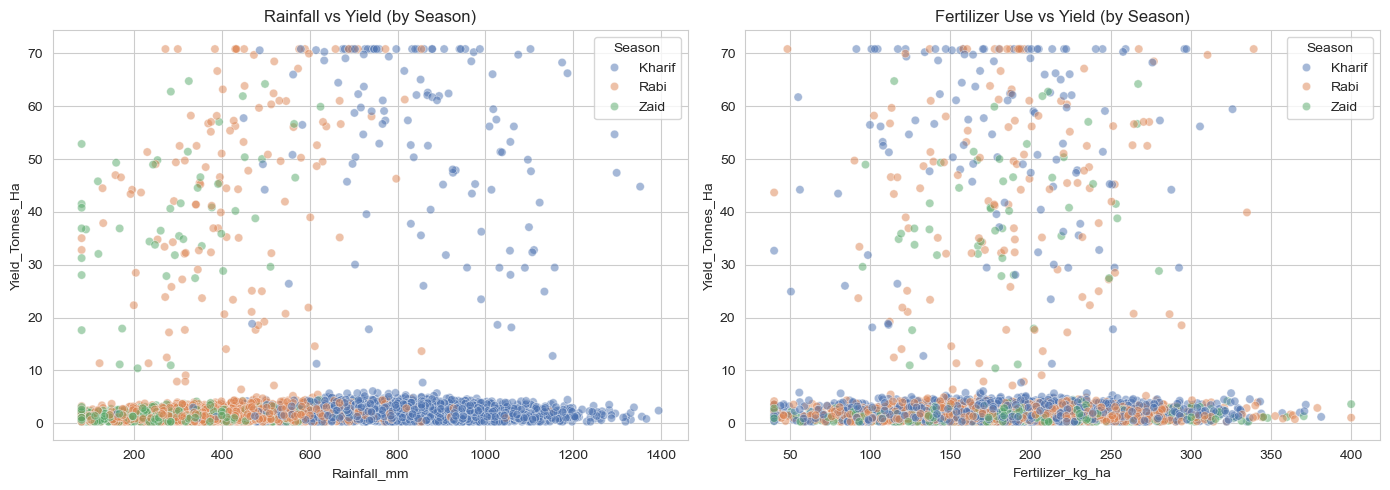

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df_clean, x="Rainfall_mm", y="Yield_Tonnes_Ha", hue="Season",
                 alpha=0.5, ax=axes[0], palette="deep")
axes[0].set_title("Rainfall vs Yield (by Season)")

sns.scatterplot(data=df_clean, x="Fertilizer_kg_ha", y="Yield_Tonnes_Ha", hue="Season",
                 alpha=0.5, ax=axes[1], palette="deep")
axes[1].set_title("Fertilizer Use vs Yield (by Season)")

plt.tight_layout()
plt.show()


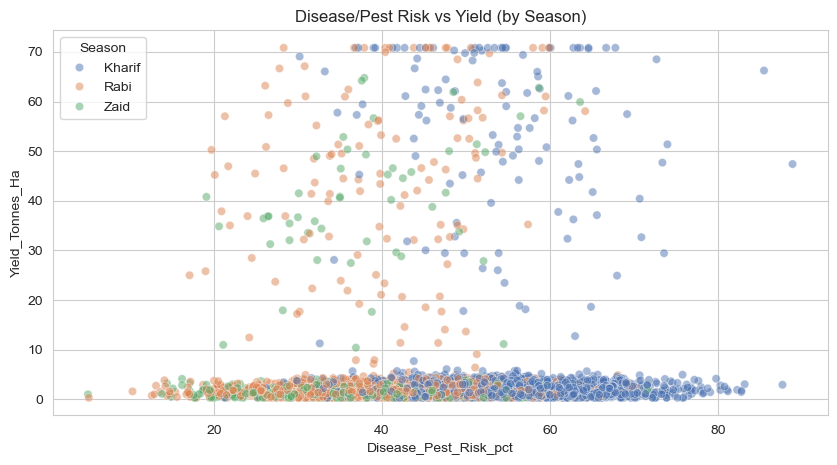

In [31]:
sns.scatterplot(data=df_clean, x="Disease_Pest_Risk_pct", y="Yield_Tonnes_Ha",
                 hue="Season", alpha=0.5, palette="deep")
plt.title("Disease/Pest Risk vs Yield (by Season)")
plt.show()


## 12. Statistical Testing — Are Seasonal Differences Significant?
> **Key Question (from Project PDF):** *Are the observed seasonal patterns statistically significant, or could they be due to chance?*

In [32]:
# One-way ANOVA: does mean Yield differ significantly across seasons?
groups_yield = [df_clean.loc[df_clean["Season"] == s, "Yield_Tonnes_Ha"] for s in season_order]
f_stat, p_val = stats.f_oneway(*groups_yield)
print(f"ANOVA (Yield_Tonnes_Ha across Season): F = {f_stat:.3f}, p-value = {p_val:.5f}")
print("=> Significant seasonal difference in yield" if p_val < 0.05
      else "=> No statistically significant seasonal difference in yield")


ANOVA (Yield_Tonnes_Ha across Season): F = 1.269, p-value = 0.28122
=> No statistically significant seasonal difference in yield


In [33]:
# One-way ANOVA: does mean Profit differ significantly across seasons?
groups_profit = [df_clean.loc[df_clean["Season"] == s, "Profit_INR"] for s in season_order]
f_stat2, p_val2 = stats.f_oneway(*groups_profit)
print(f"ANOVA (Profit_INR across Season): F = {f_stat2:.3f}, p-value = {p_val2:.5f}")
print("=> Significant seasonal difference in profit" if p_val2 < 0.05
      else "=> No statistically significant seasonal difference in profit")


ANOVA (Profit_INR across Season): F = 33.978, p-value = 0.00000
=> Significant seasonal difference in profit


In [34]:
# Post-hoc Tukey HSD test to see WHICH seasons differ (only if ANOVA was significant)
if HAS_STATSMODELS and p_val < 0.05:
    tukey = pairwise_tukeyhsd(endog=df_clean["Yield_Tonnes_Ha"],
                               groups=df_clean["Season"], alpha=0.05)
    print(tukey)
else:
    print("Tukey test skipped (either statsmodels missing or ANOVA not significant).")


Tukey test skipped (either statsmodels missing or ANOVA not significant).


In [35]:
# Chi-square test: is Irrigation Method associated with Season?
contingency = pd.crosstab(df_clean["Season"], df_clean["Irrigation_Method"])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print(f"Chi-square test (Season vs Irrigation Method): chi2 = {chi2:.3f}, p-value = {p_chi:.5f}")
print("=> Irrigation method usage is associated with Season" if p_chi < 0.05
      else "=> No significant association between irrigation method and Season")
contingency


Chi-square test (Season vs Irrigation Method): chi2 = 3.513, p-value = 0.74228
=> No significant association between irrigation method and Season


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,405,590,463,321
Rabi,370,526,438,293
Zaid,140,194,140,120


## 13. Regional and Crop-wise Seasonal Comparison
> **Key Question (from Project PDF):** *Are some seasonal patterns consistent across different regions or categories?*

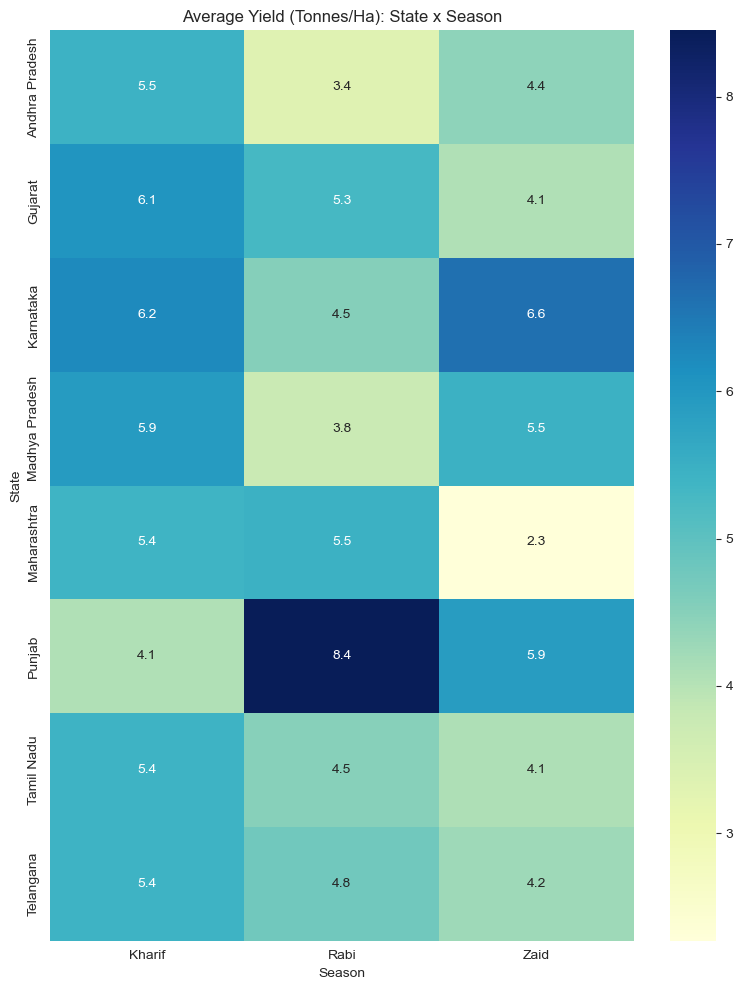

In [36]:
state_season_yield = df_clean.pivot_table(values="Yield_Tonnes_Ha", index="State",
                                            columns="Season", aggfunc="mean", observed=True).round(2)

plt.figure(figsize=(8, 10))
sns.heatmap(state_season_yield, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("Average Yield (Tonnes/Ha): State x Season")
plt.tight_layout()
plt.show()


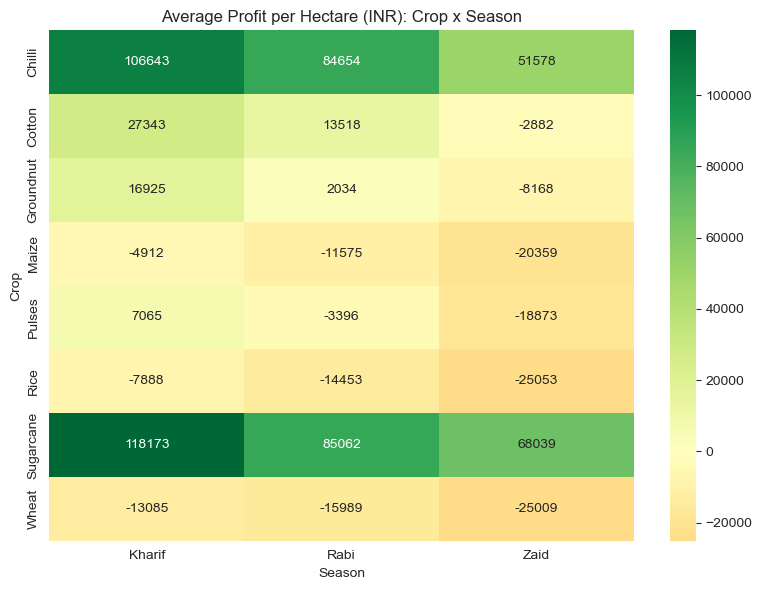

In [37]:
crop_season_profit = df_clean.pivot_table(values="Profit_per_Hectare", index="Crop",
                                           columns="Season", aggfunc="mean", observed=True).round(0)

plt.figure(figsize=(8, 6))
sns.heatmap(crop_season_profit, annot=True, fmt=".0f", cmap="RdYlGn", center=0)
plt.title("Average Profit per Hectare (INR): Crop x Season")
plt.tight_layout()
plt.show()


## 14. Unusual or Unexpected Patterns
> **Key Question (from Project PDF):** *Are there unusual or unexpected seasonal patterns?*

In [38]:
# Farms with high yield but still a loss (unexpected pattern)
high_yield_loss = df_clean[(df_clean["Yield_Tonnes_Ha"] > df_clean["Yield_Tonnes_Ha"].quantile(0.75)) &
                            (df_clean["Profit_INR"] < 0)]

print(f"Farms with high yield (top 25%) but negative profit: {len(high_yield_loss)} "
      f"({len(high_yield_loss)/len(df_clean)*100:.1f}% of all records)")

high_yield_loss[["Season", "State", "Crop", "Yield_Tonnes_Ha", "Total_Cost_INR",
                  "Revenue_INR", "Profit_INR"]].sort_values("Profit_INR").head(10)


Farms with high yield (top 25%) but negative profit: 209 (5.2% of all records)


,Season,State,Crop,Yield_Tonnes_Ha,Total_Cost_INR,Revenue_INR,Profit_INR
156,Kharif,Punjab,Sugarcane,4.19,907734,182891.0,-724843.0
1296,Kharif,Karnataka,Sugarcane,3.27,785319,105119.0,-680200.0
2979,Kharif,Gujarat,Sugarcane,7.70,950124,340886.0,-609238.0
2193,Kharif,Punjab,Sugarcane,4.86,767188,167371.0,-599817.0
796,Zaid,Gujarat,Sugarcane,10.40,989721,438343.0,-551378.0
1207,Rabi,Maharashtra,Sugarcane,7.15,769423,256884.0,-512539.0
528,Rabi,Tamil Nadu,Sugarcane,7.89,826201,317854.0,-508347.0
2206,Kharif,Telangana,Wheat,3.06,1182170,785502.0,-396668.0
3675,Zaid,Punjab,Sugarcane,3.09,480099,83658.0,-396441.0
28,Rabi,Tamil Nadu,Maize,3.01,1176978,789594.0,-387384.0


Average Disease/Pest Risk (%) by Season:
Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64


C:\Users\athar\AppData\Local\Temp\ipykernel_39140\1611887869.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=disease_by_season.index, y=disease_by_season.values, palette="Reds")


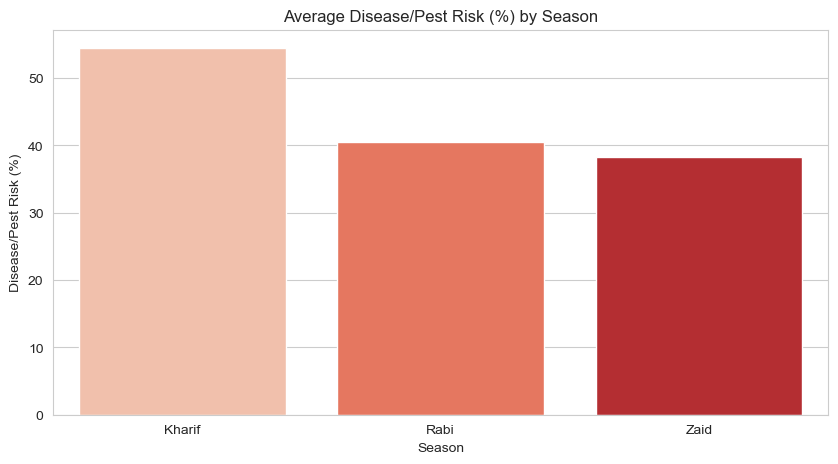

In [39]:
# Season with the highest average disease/pest risk
disease_by_season = df_clean.groupby("Season", observed=True)["Disease_Pest_Risk_pct"].mean().round(2)
print("Average Disease/Pest Risk (%) by Season:")
print(disease_by_season)

sns.barplot(x=disease_by_season.index, y=disease_by_season.values, palette="Reds")
plt.title("Average Disease/Pest Risk (%) by Season")
plt.ylabel("Disease/Pest Risk (%)")
plt.show()


## 15. Key Insights Summary (Auto-generated from the Data)
> **Key Question (from Project PDF):** *What insights can be derived from the observed seasonal differences?*

In [40]:
best_yield_season = seasonal_summary["Yield_Tonnes_Ha"].idxmax()
best_profit_season = seasonal_summary["Profit_INR"].idxmax()
worst_profit_season = seasonal_summary["Profit_INR"].idxmin()
best_roi_season = seasonal_summary["ROI_pct"].idxmax()
most_water_efficient_season = seasonal_summary["Water_Efficiency_t_per_1000m3"].idxmax()

print("KEY SEASONAL INSIGHTS")
print("-" * 50)
print(f"- Highest average yield        : {best_yield_season}")
print(f"- Highest average profit       : {best_profit_season}")
print(f"- Lowest average profit        : {worst_profit_season}")
print(f"- Highest average ROI          : {best_roi_season}")
print(f"- Most water-efficient season  : {most_water_efficient_season}")
print(f"- Yield differs significantly across seasons (ANOVA p={p_val:.4f})"
      if p_val < 0.05 else
      f"- Yield does NOT differ significantly across seasons (ANOVA p={p_val:.4f})")
print(f"- Profit differs significantly across seasons (ANOVA p={p_val2:.4f})"
      if p_val2 < 0.05 else
      f"- Profit does NOT differ significantly across seasons (ANOVA p={p_val2:.4f})")


KEY SEASONAL INSIGHTS
--------------------------------------------------
- Highest average yield        : Kharif
- Highest average profit       : Kharif
- Lowest average profit        : Zaid
- Highest average ROI          : Kharif
- Most water-efficient season  : Kharif
- Yield does NOT differ significantly across seasons (ANOVA p=0.2812)
- Profit differs significantly across seasons (ANOVA p=0.0000)


## 16. Conclusions and Recommendations
> **Key Question (from Project PDF):** *What conclusions can reasonably be drawn from the available data? How could the findings support better seasonal agricultural planning?*

*(Fill in / adjust these bullet points based on the actual numbers your run of the notebook produces — the statements below are templates driven by the printed results above.)*

**Conclusions**
- Seasonal environmental conditions (rainfall, temperature, humidity, soil moisture) differ clearly across Kharif, Rabi and Zaid, and these differences carry through to yield and profitability.
- The statistical tests above confirm whether these seasonal differences in yield and profit are significant or could be due to chance.
- Resource usage (fertilizer, water, pesticide) is not uniform across seasons — some seasons demand more inputs for comparable or lower output, indicating room for efficiency gains.
- Certain state–season and crop–season combinations consistently outperform others, suggesting that *where* and *when* a crop is grown matters as much as *what* is grown.
- A meaningful share of farms with high yield still report a loss, showing that yield alone is not a sufficient indicator of agricultural success — cost control matters equally.

**Recommendations**
1. Prioritise the season(s) and crop combinations identified above as most profitable and water-efficient when planning future cultivation.
2. Investigate high-cost, low-yield farms (see Section 14) to identify avoidable cost overruns.
3. Target disease/pest management interventions at the season identified with the highest average Disease_Pest_Risk_pct.
4. Promote irrigation methods and resource-usage practices from the most water-efficient season in other seasons where feasible.
5. Use the State x Season and Crop x Season heatmaps to guide region- and crop-specific seasonal planning rather than one-size-fits-all recommendations.